In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Implement Multiclass Classification models for student Performance Level analysis and perform comparative analysis.(Random Forest, Decision Tree, Multinomial Logistic Regression, XGBoost, K-Nearest Neighbors).

In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AML_Lab/archive (1).zip'
extract_path = '/content/data'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files:", os.listdir(extract_path))

Files: ['ptbdb_abnormal.csv', 'mitbih_test.csv', 'ptbdb_normal.csv', 'mitbih_train.csv']


In [3]:
import pandas as pd

normal = pd.read_csv('/content/data/ptbdb_normal.csv')
abnormal = pd.read_csv('/content/data/ptbdb_abnormal.csv')

# Add labels
normal['Label'] = 0   # Normal
abnormal['Label'] = 1 # Abnormal

# Combine dataset
df = pd.concat([normal, abnormal], ignore_index=True)

df.head()

,1.000000000000000000e+00,9.003241658210754395e-01,3.585899472236633301e-01,5.145867168903350830e-02,4.659643396735191345e-02,1.268233358860015869e-01,1.333063244819641113e-01,1.191247999668121338e-01,1.106158867478370667e-01,1.130470037460327148e-01,...,0.000000000000000000e+00.117,0.000000000000000000e+00.118,0.000000000000000000e+00.119,0.000000000000000000e+00.120,0.000000000000000000e+00.121,0.000000000000000000e+00.122,0.000000000000000000e+00.123,0.000000000000000000e+00.124,0.000000000000000000e+00.125,1.000000000000000000e+00.1
0,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.948983,0.505265,0.004176,0.022513,0.059550,0.107298,0.110385,0.111293,0.116558,0.118192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = df.drop('Label', axis=1)
y = df['Label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X = df.drop('Label', axis=1)
y = df['Label']

X = imputer.fit_transform(X)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree
Accuracy: 1.0
Confusion Matrix:
 [[ 834    0]
 [   0 2076]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       834
           1       1.00      1.00      1.00      2076

    accuracy                           1.00      2910
   macro avg       1.00      1.00      1.00      2910
weighted avg       1.00      1.00      1.00      2910


Random Forest
Accuracy: 1.0
Confusion Matrix:
 [[ 834    0]
 [   0 2076]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       834
           1       1.00      1.00      1.00      2076

    accuracy                           1.00      2910
   macro avg       1.00      1.00      1.00      2910
weighted avg       1.00      1.00      1.00      2910


Logistic Regression
Accuracy: 1.0
Confusion Matrix:
 [[ 834    0]
 [   0 2076]]
Classification Report:
               precision    recall  f1-score

In [10]:
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                 Model  Accuracy
0        Decision Tree  1.000000
1        Random Forest  1.000000
2  Logistic Regression  1.000000
4              XGBoost  1.000000
3                  KNN  0.999313


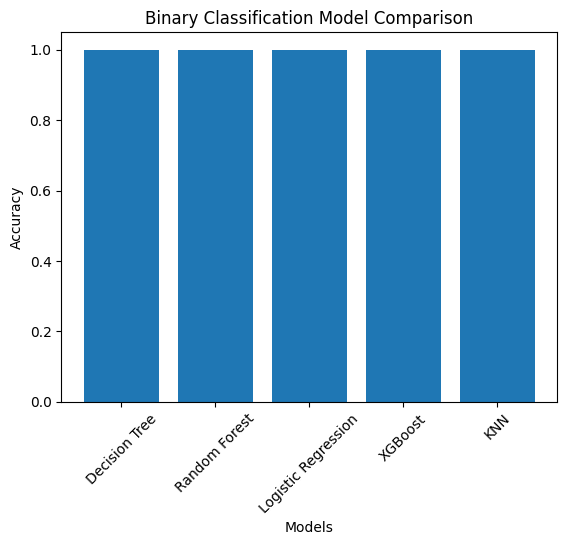

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=45)
plt.title("Binary Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

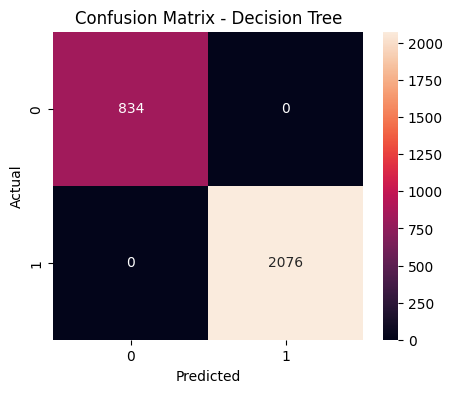

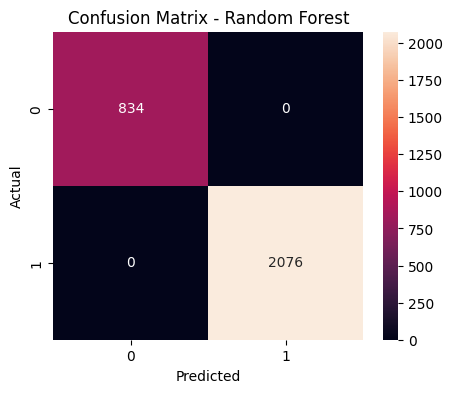

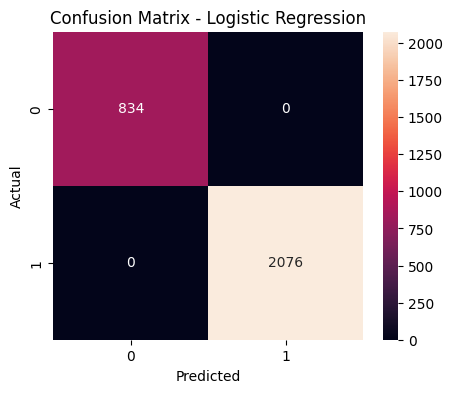

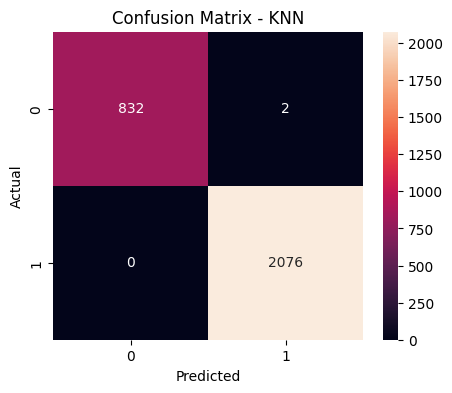

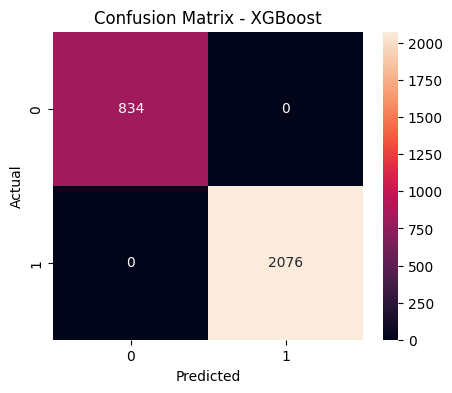

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="rocket")

    plt.title("Confusion Matrix - " + name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()